#  1 Loading Accident Data

In [1]:
import numpy as np
data = np.loadtxt("coal_mining_accident_data.dat", delimiter=None)  
data =  data.flatten() # Now all data is in a single array 190 delimiters for 191 incidents
print(data.shape)
# print(data)

(190,)


[  1.   1.   1. ... 190. 190. 191.]


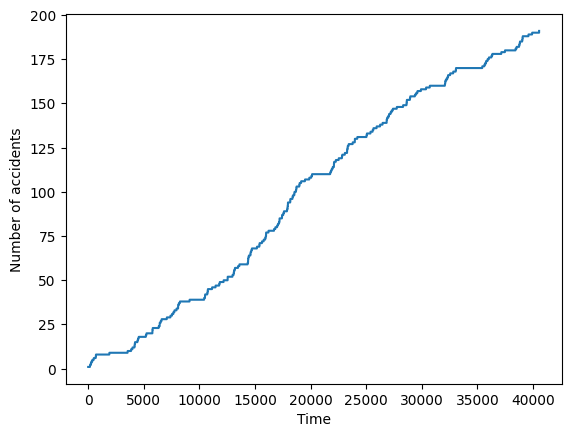

In [15]:
# Plot cumulative sum of accidents over time
import matplotlib.pyplot as plt
cumulative_accidents = np.zeros(40550) # Start with the first accident
cumulative_accidents[0] = 1
i = 0 
j = 0 # next
for interval in data:
    start = cumulative_accidents[i]
    j += int(interval)
    while i < j:
        cumulative_accidents[i] = start
        i += 1 # This ends when i == j
    cumulative_accidents[j] = start + 1

print(cumulative_accidents)
plt.plot(range(40550), cumulative_accidents)
plt.xlabel("Time")
plt.ylabel("Number of accidents")
plt.show()


# 2a Plain vs Even order stats

The plain-order-statistics draws k points and sorts them. This allows the adjacent points to be very close together. By drawing more points than required and then taking alterating points from a sorted array of them, this forces a degree of seapration between the change points we are using as a prior. This reduces the probability of very small gaps between neighbours, favouring more separated change points.

This can improve performance because it encourages the model to use all of the change points: if two change points are too close together in the prior, the model might fit them as one.

In [33]:
np.random.seed(1701)

def gaps(samples, L):
    left = [0]
    right = [L]
    full = np.concatenate(left, samples, right)
    gaps = [(full[i] - full[i-1]) for i in range(1, len(full))]
    return gaps

def even_stats(k=4):
    even_rand = [np.random.uniform() for i in range((2*k+1))]
    even_sorted = np.sort(even_rand)
    even = even_sorted[1::2]    
    return even

def plain_stats(k=4):
    plain_rand = [np.random.uniform() for i in range(k)]
    plain = np.sort(plain_rand) 
    return plain


[0.08943323 0.21284218 0.51874394 0.87998291]
[0.17048354 0.32926726 0.32940442 0.68156025]


C:\Users\Joey\AppData\Local\Temp\ipykernel_25084\1298909841.py:23: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


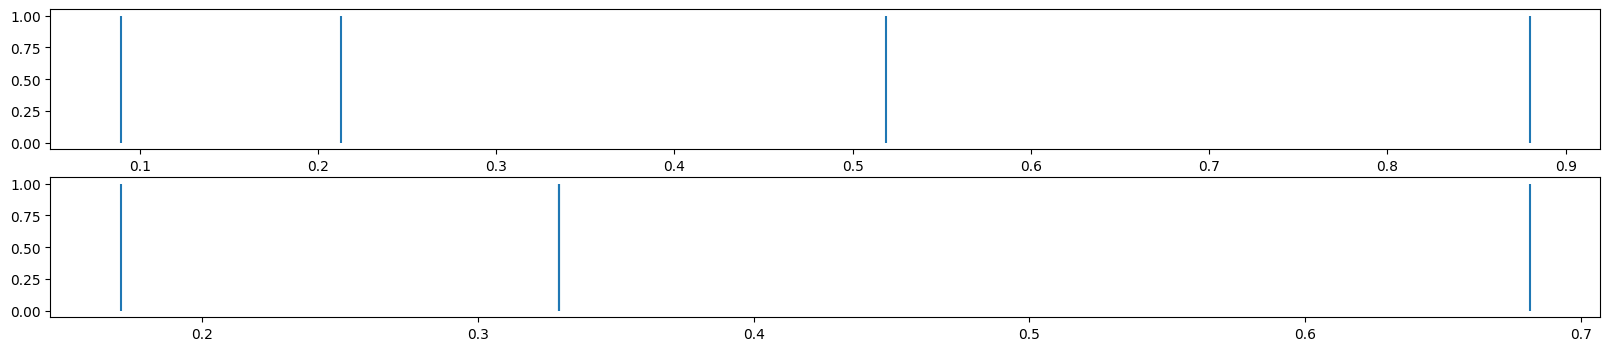

In [ ]:
# Plot single example
np.random.seed(1701)
k = 4

# Even order stats
# even_rand = [np.random.uniform() for i in range((2*k+1))]
# even_sorted = np.sort(even_rand)
# even = even_sorted[1::2]
even = even_stats()

# Plain stats
# plain_rand = [np.random.uniform() for i in range(k)]
# plain = np.sort(plain_rand)
plain = plain_stats()

print(even)
print(plain)

fig, ax = plt.subplots(2, figsize=(20, 4))

ax[0].vlines(even, 0, 1)
ax[1].vlines(plain,0, 1)
fig.show()




The middle line on the plain-statistics draw (the bottom subplot) shows is actually two draws that are very close to one another. We can try to look at this for a larger number of draws by plotting the distribution of the size of gaps between the generated change points.

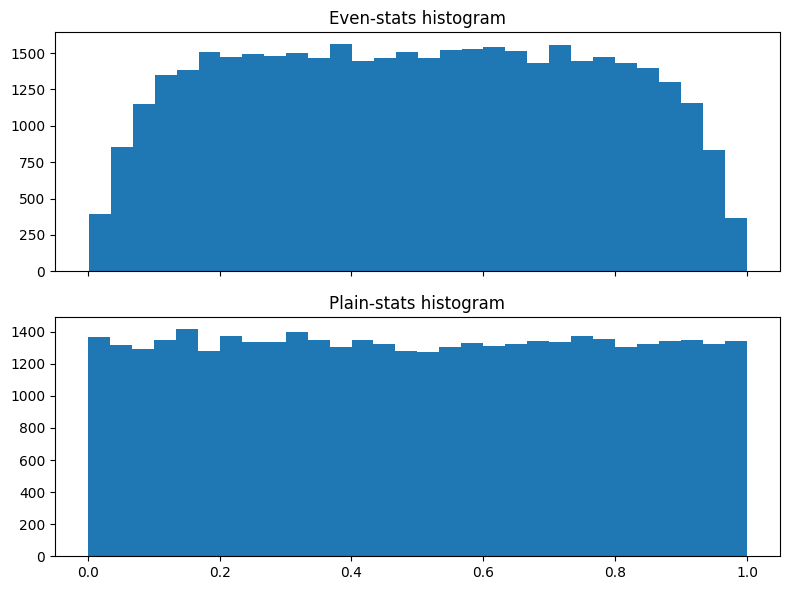

In [41]:
even_gaps = []
plain_gaps =[]
for i in range(0,10000):
    even_gaps.append(even_stats())
    plain_gaps.append(plain_stats())

even_gaps = np.array(even_gaps).flatten()
plain_gaps = np.array(plain_gaps).flatten()

# Plot them in two subplot histograms

fig, axs = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

axs[0].hist(even_gaps, bins=30)
axs[0].set_title("Even-stats histogram")

axs[1].hist(plain_gaps, bins=30)
axs[1].set_title("Plain-stats histogram")

plt.tight_layout()
plt.show()

This shows that our even-stats regime reduces the probability of very close together initial change-points. To have very high separations, the points have to be clumped at the ends so the reduction in clumping behaviour will also have the side effect of reducing very separated points too. This creates a consistent separation between change points.